# Heart Disease Risk Prediction

**Dataset:** `heart_disease_risk_dataset_earlymed.csv`
**Goal:** Predict `Heart_Risk` (0 = Low risk, 1 = High risk) from symptoms and risk factors, maximizing predictive accuracy.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import joblib

RANDOM_STATE = 42
sns.set_style("whitegrid")


## 2. Load the data

In [2]:
df = pd.read_csv("heart_disease_risk_dataset_earlymed.csv")
print("Shape:", df.shape)
df.head()


Shape: (70000, 19)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null  float64
 1

## 3. Clean the data

Check for and remove duplicate rows, and confirm there are no missing values.


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Missing values per column:
Chest_Pain             0
Shortness_of_Breath    0
Fatigue                0
Palpitations           0
Dizziness              0
Swelling               0
Pain_Arms_Jaw_Back     0
Cold_Sweats_Nausea     0
High_BP                0
High_Cholesterol       0
Diabetes               0
Smoking                0
Obesity                0
Sedentary_Lifestyle    0
Family_History         0
Chronic_Stress         0
Gender                 0
Age                    0
Heart_Risk             0
dtype: int64

Duplicate rows: 6245
Shape after dropping duplicates: (63755, 19)


## 4. Explore class balance and features

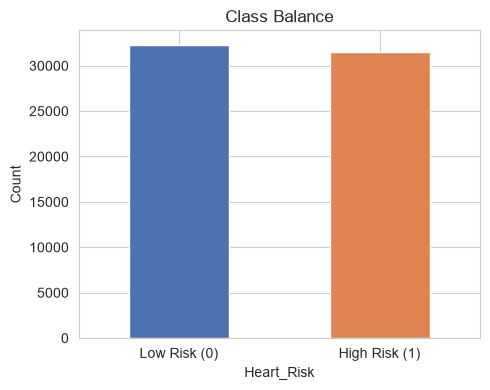

Heart_Risk
0.0    0.506125
1.0    0.493875
Name: proportion, dtype: float64

In [5]:
ax = df["Heart_Risk"].value_counts().sort_index().plot(
    kind="bar", color=["#4C72B0", "#DD8452"], figsize=(5, 4)
)
ax.set_xticklabels(["Low Risk (0)", "High Risk (1)"], rotation=0)
ax.set_title("Class Balance")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

df["Heart_Risk"].value_counts(normalize=True)


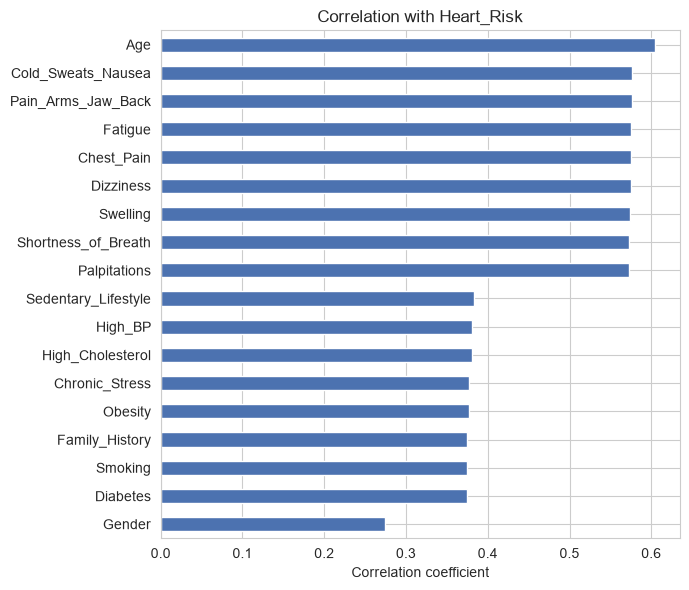

In [7]:
# Correlation of each feature with the target
corr = df.corr(numeric_only=True)["Heart_Risk"].drop("Heart_Risk").sort_values()

plt.figure(figsize=(7, 6))
corr.plot(kind="barh", color="#4C72B0")
plt.title("Correlation with Heart_Risk")
plt.xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()


## 5. Train / test split

In [8]:
X = df.drop(columns=["Heart_Risk"])
y = df["Heart_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (51004, 18)
Test shape: (12751, 18)


In [9]:
# Scaled versions (needed for Logistic Regression; tree models don't need it)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Train and compare models

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    ),
}

results = []
fitted_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    if name == "Logistic Regression":
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    # 5-fold cross-validation on the training set
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]

    fitted_models[name] = model
    results.append({
        "Model": name,
        "CV_Accuracy_Mean": cv_scores.mean(),
        "CV_Accuracy_Std": cv_scores.std(),
        "Test_Accuracy": accuracy_score(y_test, pred),
        "Test_Precision": precision_score(y_test, pred),
        "Test_Recall": recall_score(y_test, pred),
        "Test_F1": f1_score(y_test, pred),
        "Test_ROC_AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).sort_values("Test_ROC_AUC", ascending=False).reset_index(drop=True)
print(results_df)


                 Model  CV_Accuracy_Mean  CV_Accuracy_Std  Test_Accuracy  \
0              XGBoost          0.991197         0.000891       0.992157   
1        Random Forest          0.990942         0.001208       0.991530   
2  Logistic Regression          0.990883         0.000641       0.991060   

   Test_Precision  Test_Recall   Test_F1  Test_ROC_AUC  
0        0.991435     0.992695  0.992065      0.999688  
1        0.990490     0.992377  0.991433      0.999660  
2        0.991104     0.990789  0.990947      0.999604  


## 7. Pick the best model and evaluate it in detail

In [13]:
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
print(f"Best model: {best_name}")

X_eval = X_test_scaled if best_name == "Logistic Regression" else X_test
pred = best_model.predict(X_eval)
proba = best_model.predict_proba(X_eval)[:, 1]

print(classification_report(y_test, pred, target_names=["Low Risk", "High Risk"]))


Best model: XGBoost
              precision    recall  f1-score   support

    Low Risk       0.99      0.99      0.99      6454
   High Risk       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751



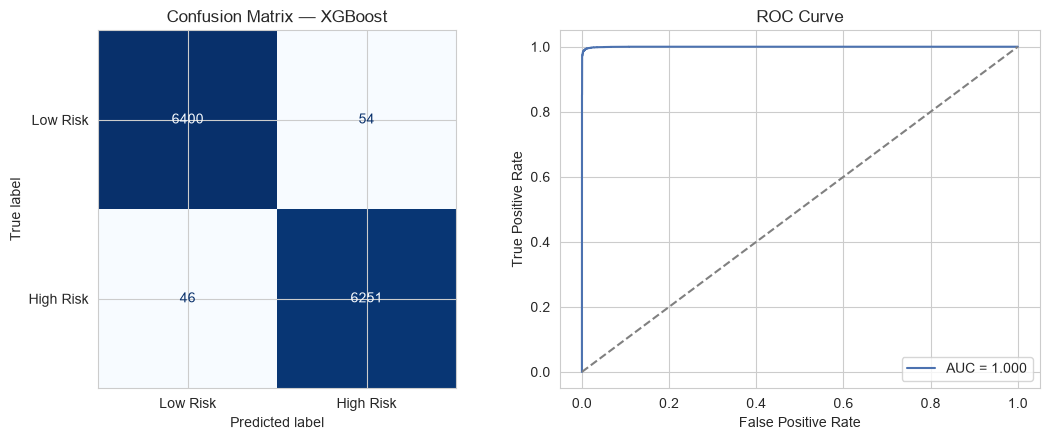

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Confusion matrix
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title(f"Confusion Matrix — {best_name}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="#4C72B0")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Feature importance

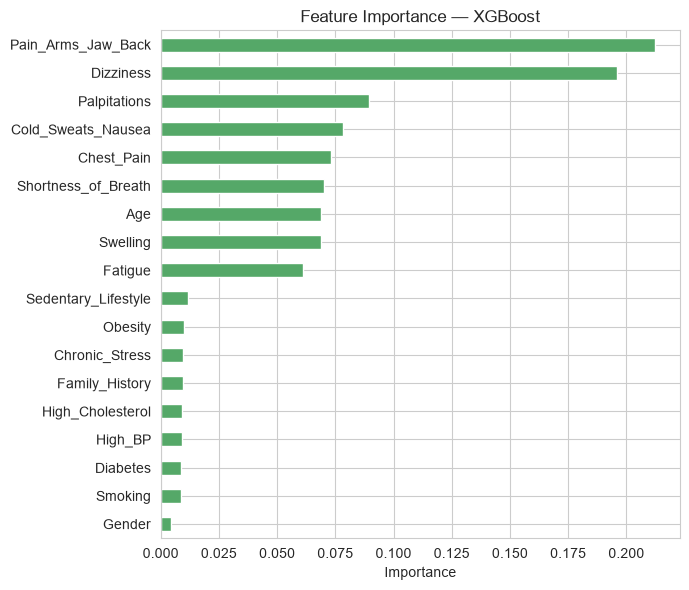

In [15]:
if best_name in ("Random Forest", "XGBoost"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(7, 6))
    importances.plot(kind="barh", color="#55A868")
    plt.title(f"Feature Importance — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefs = pd.Series(best_model.coef_[0], index=X.columns).sort_values()
    plt.figure(figsize=(7, 6))
    coefs.plot(kind="barh", color="#55A868")
    plt.title("Logistic Regression Coefficients")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()


## 9. Save the best model

In [16]:
joblib.dump(best_model, "heart_risk_best_model.joblib")
joblib.dump(scaler, "heart_risk_scaler.joblib")  # only needed if best model is Logistic Regression

print(f"Saved '{best_name}' to heart_risk_best_model.joblib")


Saved 'XGBoost' to heart_risk_best_model.joblib


## Summary

- Trained and compared Logistic Regression, Random Forest, and XGBoost on the cleaned, balanced CSV dataset (70,000 rows → deduplicated).
- Evaluated with 5-fold cross-validation plus a held-out 20% test set (accuracy, precision, recall, F1, ROC-AUC).
- Identified the strongest predictive features via importance/coefficient analysis.
- Saved the best-performing model for reuse.


## Inspecting Cases

In [26]:
def inspect_case(row_number, X_test=X_test, y_test=y_test, model=best_model, model_name=best_name, scaler=scaler):
    """Show one test-set case: it's features, the true tabel, and the model's prediction."""
    row_features = X_test.iloc[[row_number]]
    actual_label = y_test.iloc[row_number]

    row_for_model=row_features
    predicted_label = model.predict(row_for_model)[0]
    predicted_proba = model.predict_proba(row_for_model)[0][1]

    label_map = {0: "Low Risk", 1: "High Risk"}
    print(f"Case #{row_number}")
    print("-"*40)
    print("Feature values:")
    print(row_features.T.rename(columns={row_features.index[0]: "value"}))
    print(f"Actual label: {label_map[actual_label]} ({actual_label})")
    print(f"Predicted Label: {label_map[predicted_label]} ({predicted_label})")
    print(f"Predicted probability of High Risk: {predicted_proba:.2%}")
    print(f"Correct prediction? {'YES' if actual_label == predicted_label else 'NO'}")

row_number = 8
inspect_case(row_number)

    




Case #8
----------------------------------------
Feature values:
                     value
Chest_Pain             1.0
Shortness_of_Breath    1.0
Fatigue                1.0
Palpitations           1.0
Dizziness              1.0
Swelling               0.0
Pain_Arms_Jaw_Back     0.0
Cold_Sweats_Nausea     1.0
High_BP                1.0
High_Cholesterol       1.0
Diabetes               1.0
Smoking                0.0
Obesity                0.0
Sedentary_Lifestyle    0.0
Family_History         0.0
Chronic_Stress         1.0
Gender                 1.0
Age                   46.0
Actual label: High Risk (1.0)
Predicted Label: High Risk (1)
Predicted probability of High Risk: 99.96%
Correct prediction? YES


In [31]:
def actual_vs_predicted_table(n=5, X_test = X_test, y_test = y_test, model = best_model, model_name = best_name, scaler =scaler):
    X_for_model = scalar.transform(X_test.iloc[:n]) if model_name == "Logistic Regression" else X_test.iloc[:n]
    preds = model.predict(X_for_model)
    probs = model.predict_proba(X_for_model)[:, 1]

    label_map = {0: "Low Risk", 1: "High Risk"}
    comparison = pd.DataFrame({
    "row_number": range(n),
    "Actual": [label_map[v] for v in y_test.iloc[:n].values],
    "Predicted": [label_map[v] for v in preds],
    "Predicted_Prob_HighRisk": probs.round(3),
    "Correct?":y_test.iloc[:n].values == preds,

    })
    return comparison
actual_vs_predicted_table(15)

,row_number,Actual,Predicted,Predicted_Prob_HighRisk,Correct?
0,0,Low Risk,Low Risk,0.000,True
1,1,Low Risk,Low Risk,0.000,True
2,2,High Risk,High Risk,1.000,True
3,3,High Risk,High Risk,1.000,True
4,4,High Risk,High Risk,0.999,True
5,5,High Risk,High Risk,1.000,True
6,6,High Risk,High Risk,1.000,True
7,7,High Risk,High Risk,1.000,True
8,8,High Risk,High Risk,1.000,True
9,9,High Risk,High Risk,1.000,True
